In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.inspection import permutation_importance

# Data Preparation

After initial Data Exploration, the following columns are dropped:

- **Source IP, Destination IP**: Since the rows were aggregated by flow ids which include these in the quintuple, the specific IP Addresses by themselves do not provide any signal
- **SimillarHTTP**: this is related to the certificate information for connections which are not pertinent to the network layers 3/4 that is being analyzed
- **Flow ID**: The ID by itself is just a number and does not provide any information. The columns are aggregated per flow which is more meaningful
- **Timestamp**: For now only static analysis is being done, meaning there is no real-time detection of the attacks. Timestamp will be used in future when features like bursty traffic, etc. can be analyzed to do real time detection using time series data
- **Unnamed**: this is again an id that seems to be left behind in the dataset and does not provide any signal

Cleans data by replacing float.inf values in the data by the max value of that column

Convert Label column to binary values 0 and 1 where 0 denotes BENIGN traffic and 1 denotes DDoS attack

In [75]:
'''
This function cleans the raw dataframe created from the file on disk
    - It drops columns that do not provide a signal
    - there are some inf values in some columns
    - converts the Label (target) column to binary (0 for BENIGN) 
'''

def clean_data(data_df):

    drop = [
            'Source IP', 
            'Destination IP', 
            'SimillarHTTP', 
            'Flow ID', 
            'Timestamp', 
            'Unnamed: 0'
           ]
    
    data_df.drop(drop, 
             axis=1, 
             inplace=True)
    
    # there are some inf values that we will impute with the max
    # values for that column
    data_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in ['Flow Bytes/s', 'Flow Packets/s']:
        max_val = data_df[col].max()
        data_df[col] = data_df[col].fillna(max_val)

    # change label to int (0 or 1) from object (0 if BENIGN)
    data_df['Label'] = data_df['Label'].map(lambda x: 0 if x=='BENIGN' else 1)

# Model Training

For each of the estimators, a grid search is done to tune the hyper parameters while training.
Following grid parameters were chosen to search over each of the estimators:

- **LinearRegression**: {'lgr__penalty': ['l2'], 'lgr__C': [0.01, 0.1, 1, 10]}
- **BaggingClassifier**: {'n_estimators': [5, 10, 15], 'max_samples': [0.4, 0.7, 1.0]},
- **RandomForestClassifier**: {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 100]},
- **AdaBoostClassifier**: {'n_estimators': [25, 50, 75], 'learning_rate': [0.6, 0.8, 1.0]},
- **GridentBoostingClassifier**: {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.5]}



In [76]:
'''
This function trains estimators and tunes the hyper parameters
'''

def train_grid(estimators,
               params,
               X_train,
               y_train):
    grids = []
    for i, estimator in enumerate(estimators):
        grid = GridSearchCV(estimator, param_grid=params[i], cv=5)
        grid.fit(X_train, y_train)
        grids.append(grid)

    return grids

# Model Evaluation and Metrics visualization

The models are evaluated based on following metrics:

-  **Accuracy score**
-  **Roc_auc score**
-  **Precision score**
-  **Recall score**

The metrics are visualized by displaying:

- **Confusion Matrices** for each estimator
- **Roc-Auc curve** for each estimator
- **Precision-Recall curve** for each estimator
- **Metrics Table** comparing each estimator

In [6]:
'''
This function scores the trained estimators on the test data
provided
returns lists of 
    - accuracy scores
    - roc/auc scores
    - precision scores
    - recall scores
'''

def score_estimators(trained_estimators,
                     X_test,
                     y_test):
    scores = []
    roc_auc_scores = []
    precision_scores = []
    recall_scores = []

    for i, estimator in enumerate(trained_estimators):
        scores.append(estimator.score(X_test, y_test))
        preds = estimator.predict(X_test)
        roc_auc_scores.append(roc_auc_score(y_test, preds))
        precision_scores.append(precision_score(y_test, preds))
        recall_scores.append(recall_score(y_test, preds))
        
    return scores, roc_auc_scores, precision_scores, recall_scores
    

In [7]:
'''
This function visualizes metrics given the trained estimators
It displays for each estimator
    - Confusion Matrices
    - Roc Curve
    - Precision/Recall curve
'''

def display_metrics(trained_estimators, 
                    estimator_names, 
                    X_test, 
                    y_test):

    # display confusion matrices for each of the estimators
    fig, axes = plt.subplots((len(trained_estimators)//3) + 1, 3, figsize=(10,6))
    fig.suptitle('Confusion matrix comparision for different estimators')
    for i, estimator in enumerate(trained_estimators):
        row, col = i//3, i%3
        ConfusionMatrixDisplay.from_estimator(estimator,
                                              X_test,
                                              y_test,
                                              ax=axes[row, col])
        axes[row, col].set_title(estimator_names[i])
        
    for i in range(len(trained_estimators), (1 + (len(trained_estimators)//3)) * 3):
        axes[i//3, i%3].axis('off')

    plt.tight_layout()
    plt.show()

    # display Roc Curves and Precision Recall curves
    fig, axes = plt.subplots(1, 2, figsize=(10,6))
    for i, estimator in enumerate(trained_estimators):
        RocCurveDisplay.from_estimator(estimator,
                                       X_test,
                                       y_test,
                                       name=estimator_names[i],
                                       ax=axes[0])
        axes[0].set_title('ROC-AUC')
        
        PrecisionRecallDisplay.from_estimator(estimator,
                                              X_test,
                                              y_test,
                                              name=estimator_names[i],
                                              ax=axes[1])
        axes[1].set_title('Precision Recall')
        
    plt.tight_layout()
    plt.show()
        
    

# Deployment/Recommendations

For each estimator, the features impacting most are displayed

In [8]:
'''
This function displays feature importance for each trained estimator
'''

def display_feature_importance(trained_estimators, 
                               X_test, 
                               y_test, 
                               estimator_names,
                               feature_names):

    for i, estimator in enumerate(trained_estimators):
        print(f'Estimator: {estimator_names[i]}:')
        print()
        
        r = permutation_importance(estimator, 
                                   X_test, 
                                   y_test,
                                   n_repeats=30,
                                   random_state=0)
        
        for i in r.importances_mean.argsort()[::-1]:
            if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
                print(f"{feature_names[i]:<30}"
                      f"{r.importances_mean[i]:.7f}"
                      f" +/- {r.importances_std[i]:.7f}")
        print()

In [69]:
'''
This function creates a dataframe given various scores
'''

def create_scores_df(trained_estimators,
                     estimator_names,
                     scores,
                     roc_auc_scores,
                     precision_scores,
                     recall_scores):
    scores_df = pd.DataFrame({'estimator': estimator_names,
                          'accuracy': scores,
                          'roc_auc': roc_auc_scores,
                          'precision': precision_scores,
                          'recall': recall_scores,
                          'best_params': [grid.best_params_ for grid in trained_estimators]}).set_index('estimator')
    scores_df = scores_df.sort_values(by='accuracy', ascending=False)
    return scores_df

In [36]:
'''
This function plots the scores to compare the scores
for different estimators
'''

def display_scores(df):
    for column in df.columns:
        plt.plot(df.index, df[column], '-o')    
    plt.legend(df.columns)
    plt.ylim(min(df.min()), 1)
    plt.xticks(rotation=45)
    plt.ylabel('score (zoomed in)')
    plt.title('scores for classifiers')
    plt.tight_layout()
    plt.show()

In [97]:
'''
This function visualizes the results given dataframe and trained estimators 
'''

def visualize_results_df(test_df, 
                         trained_estimators, 
                         X_test_data=None, 
                         y_test_data=None,
                         protocol='All protocols'):

    print(f'************************ Results for protocol: {protocol} *******************************')
    print()
    
    if X_test_data is None:
        X_test_data, y_test_data = test_df.drop('Label', axis=1), test_df['Label']
        
    test_accuracy, test_auc_roc, test_precision, test_recall = score_estimators(trained_estimators,
                                                                                 X_test_data,
                                                                                 y_test_data)
    display_metrics(trained_estimators, estimator_names, X_test_data, y_test_data)
    test_scores_df = create_scores_df(trained_estimators,
                                      estimator_names,
                                      test_accuracy,
                                      test_auc_roc,
                                      test_precision,
                                      test_recall)

    print()
    print()
    print(" Metrics comparison for different estimators")
    print("--------------------------------------------------")
    print()
    
    display(test_scores_df)
    display_scores(test_scores_df.drop('best_params', axis=1))

    return test_scores_df

In [38]:
'''
This function loads the data from various protocol data files. The methodology
followed is to collect the 'BENIGN' rows which indicate normal user activity
(not attack flows) from each of the protocol files and aggregate them to be
used for training and validation. This is done beacuse the number of BENIGN rows
are very small compared to the attack rows

'files' parameter is the list of file prefixes that indicate the protocol data
files
'nrows' indicate the number of rows to load from each file. By default all rows
in the file are read
'''

def load_data(files, nrows=None):

    data_files_df = pd.DataFrame()
    benign_df = pd.read_csv('data/CICDDos2019/sampled_data/aggreggated_benign.csv', low_memory=False)
    for file in files:        
        data_files_df = pd.concat([
            data_files_df, 
            pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file}.csv', 
                        low_memory=False,
                        nrows=nrows)
        ])

    # remove the benign rows from individual protocol files
    data_files_df = data_files_df.loc[data_files_df['Label'] != 'BENIGN']

    # add all benign rows
    data_files_df = pd.concat([data_files_df, benign_df])
    
    # shuffle the data
    data_files_df = data_files_df.sample(frac=1, random_state=42)
    clean_data(data_files_df)
    return data_files_df
    

In [78]:
'''
This method visualizes the results in the form of confusion-matrix, roc-auc, 
precision, recall curves. It also displays a dataframe indicating the accuracy
and other metrics

'testfile' is the file to be used as test data
'trained_estimators' is the list of estimators already trained
'''
def visualize_results(testfile, trained_estimators):
    return visualize_results_df(load_data([testfile]), trained_estimators)

In [79]:
def visualize_results_test(estimators):
    test_files = [
                 'DrDoS_DNS_2',
                 'DrDoS_LDAP_1',
                 'DrDoS_MSSQL_2',
                 'DrDoS_NetBIOS_1',
                 'DrDoS_NTP_2',
                 'DrDoS_SNMP_1',
                 'DrDoS_SSDP_2',
                 'DrDoS_UDP_1',
                 'Syn_2',
                 'TFTP_1',
                 'UDPLag_2'
                ]
    test_df = load_data(test_files).drop(drop_columns, axis=1)
    print(f'loaded test files, num test rows = {test_df.shape[0]}')
    return visualize_results_df(test_df, estimators)

In [57]:
files = [
         'DrDoS_DNS_1',
         'DrDoS_LDAP_2',
         'DrDoS_MSSQL_1',
         'DrDoS_NetBIOS_2',
         'DrDoS_NTP_1',
         'DrDoS_SNMP_2',
         'DrDoS_SSDP_1',
         'DrDoS_UDP_2',
         'Syn_1',
         'TFTP_2',
         'UDPLag_1'
        ]

# Data Preparation

Data is analyzed to identify any features with high correlation with target. This is done to remove any bias in the data collected that would result in overfitting the model and thus not generalizing well

From below analysis, we remove the following features with the hope that the trained model would generalize better:

- **Inbound**: Most the attack traffic is marked as Inbound and BENIGN traffic as not Inbound. This column acts as a proxy for the target and it is very normal that BENIGN traffic could also be Inbound
- **Down/Up Ratio**: This is a calculated feature in a flow that is removed because of similar reasoning as above
- **URG Flag Count**: The URG flag in the TCP header is not being set for the automated traffic. This is not true in real traffic



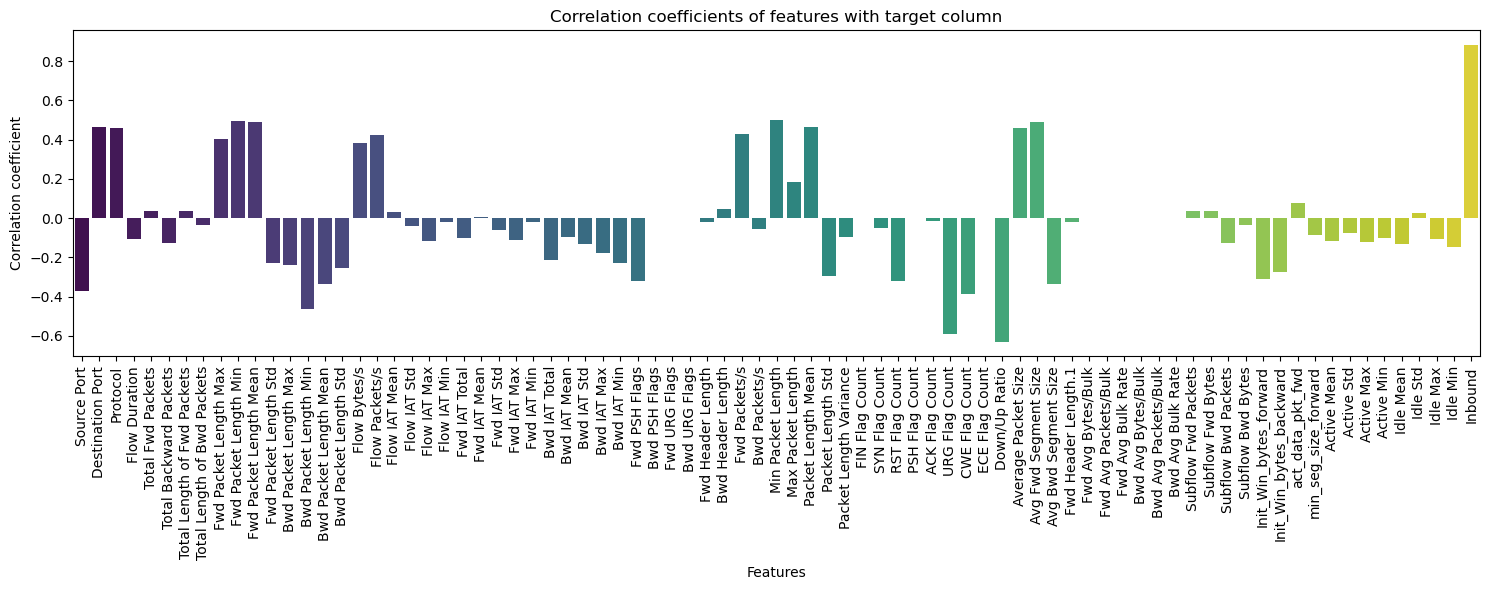

In [96]:
# visualize correlation of featuers with target
data_df = load_data(files, nrows=15_000)

corr_matrix = data_df.corr()
corr_no_label = corr_matrix['Label'].drop('Label')

plt.figure(figsize=(15,6))
plt.title('Correlation coefficients of features with target column')
sns.barplot(x=corr_no_label.index, y=corr_no_label, hue=corr_no_label.index, palette='viridis', legend=False)
plt.ylabel('Correlation coefficient')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [43]:
corr_no_label.loc[np.abs(corr_no_label) > 0.5]

URG Flag Count   -0.591419
Down/Up Ratio    -0.629420
Inbound           0.880866
Name: Label, dtype: float64

In [58]:
drop_columns = corr_no_label.loc[np.abs(corr_no_label) > 0.5].index

In [59]:
data_df = load_data(files, nrows=15_000).drop(drop_columns, axis=1)
data_df.shape

(221863, 79)

In [60]:
X, y = data_df.drop(['Label'], axis=1), data_df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((166397, 78), (166397,), (55466, 78), (55466,))

In [22]:
data_df['Label'].value_counts(normalize=True)

Label
1    0.743702
0    0.256298
Name: proportion, dtype: float64

In [81]:
estimators = [
               Pipeline([('sclaler', StandardScaler()),
                       ('lgr', LogisticRegression(random_state=42, max_iter=500))]),
               BaggingClassifier(random_state=42),
               RandomForestClassifier(random_state=42),
               AdaBoostClassifier(random_state=42),
               GradientBoostingClassifier(random_state=42)
             ]

estimator_names = [
                    'LogisticRegression',
                    'BaggingClassifier',
                    'RandomForestClassifier',
                    'AdaBoostClassifier',
                    'GrandientBoostingClassifier'
                  ]

grid_params = [
               {'lgr__penalty': ['l2'], 'lgr__C': [0.01, 0.1, 1, 10]},
               {'n_estimators': [5, 10, 15], 'max_samples': [0.4, 0.7, 1.0]},
               {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 100]},
               {'n_estimators': [25, 50, 75], 'learning_rate': [0.6, 0.8, 1.0]},
               {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.5]}
              ]

## Train estimators with grid search

Note that the estimators are trained with X and y and not with split values. This is done because we will validate the models with the rows read from attack files which are not used for training (new test rows as far as the trained models are concerned)

In [62]:
start_time = time.time()
grids = train_grid(estimators, grid_params, X, y)
end_time = time.time()
print(f'time taken to train = {end_time-start_time}')

time taken to train = 3184.67183470726


In [ ]:
visualize_results_df(data_df, grids, X_train, y_train)

loaded test files, num test rows = 973498
************************ Results for protocol: All protocols *******************************



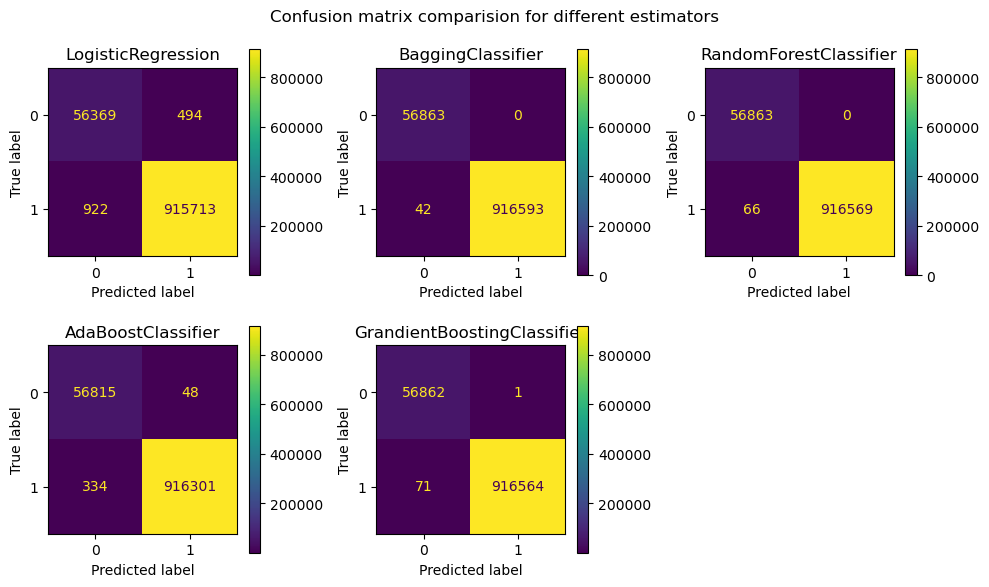

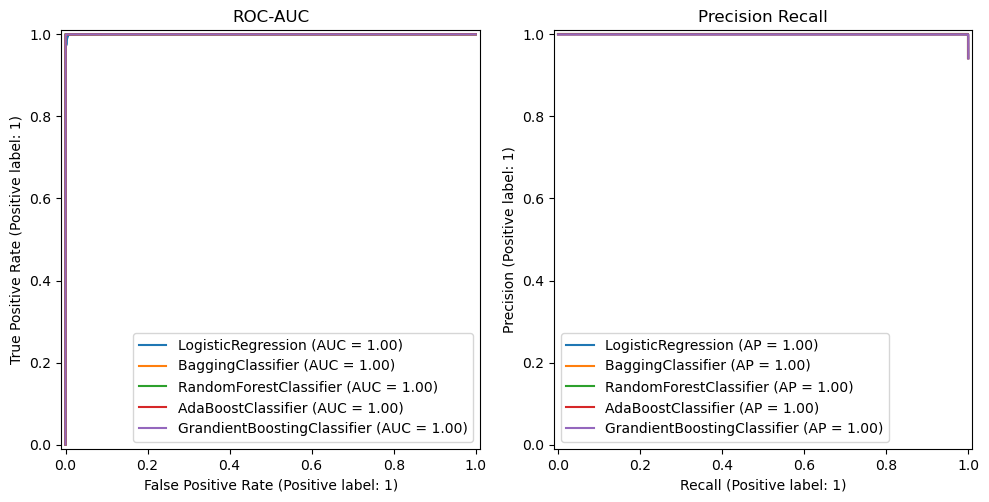



 Metrics comparison for different estimators
--------------------------------------------------



,accuracy,roc_auc,precision,recall,best_params
estimator,,,,,
BaggingClassifier,0.999957,0.999977,1.000000,0.999954,"{'max_samples': 1.0, 'n_estimators': 15}"
RandomForestClassifier,0.999932,0.999964,1.000000,0.999928,"{'max_depth': 100, 'n_estimators': 100}"
GrandientBoostingClassifier,0.999926,0.999952,0.999999,0.999923,"{'learning_rate': 0.5, 'n_estimators': 50}"
AdaBoostClassifier,0.999608,0.999396,0.999948,0.999636,"{'learning_rate': 1.0, 'n_estimators': 75}"
LogisticRegression,0.998545,0.995153,0.999461,0.998994,"{'lgr__C': 0.1, 'lgr__penalty': 'l2'}"


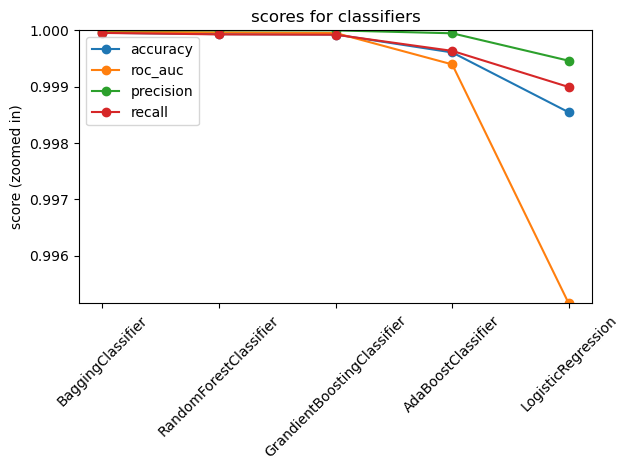

In [98]:
scores_df = visualize_results_test(grids)

In [88]:
print(scores_df.to_markdown())

| estimator                   |   accuracy |   roc_auc |   precision |   recall | best_params                                |
|:----------------------------|-----------:|----------:|------------:|---------:|:-------------------------------------------|
| BaggingClassifier           |   0.999957 |  0.999977 |    1        | 0.999954 | {'max_samples': 1.0, 'n_estimators': 15}   |
| RandomForestClassifier      |   0.999932 |  0.999964 |    1        | 0.999928 | {'max_depth': 100, 'n_estimators': 100}    |
| GrandientBoostingClassifier |   0.999926 |  0.999952 |    0.999999 | 0.999923 | {'learning_rate': 0.5, 'n_estimators': 50} |
| AdaBoostClassifier          |   0.999608 |  0.999396 |    0.999948 | 0.999636 | {'learning_rate': 1.0, 'n_estimators': 75} |
| LogisticRegression          |   0.998545 |  0.995153 |    0.999461 | 0.998994 | {'lgr__C': 0.1, 'lgr__penalty': 'l2'}      |


## Deployment

List features that are most impactful towards determining the target. This will help identify the most meaningful features that impact whether network traffic indicates a DDoS attack or not

In [89]:
start_time = time.time()
display_feature_importance(grids, 
                           X_test, 
                           y_test, 
                           estimator_names,
                           X.columns)
end_time = time.time()
print(f'time = {end_time-start_time}')

Estimator: LogisticRegression:

ACK Flag Count                0.1277239 +/- 0.0008530
Packet Length Mean            0.0400768 +/- 0.0005985
Protocol                      0.0284481 +/- 0.0003941
Average Packet Size           0.0256511 +/- 0.0005971
Fwd Packet Length Mean        0.0252713 +/- 0.0006143
Avg Fwd Segment Size          0.0252713 +/- 0.0006143
Min Packet Length             0.0211241 +/- 0.0005780
Init_Win_bytes_backward       0.0134497 +/- 0.0002868
Fwd Packet Length Std         0.0076449 +/- 0.0002248
Fwd Packet Length Min         0.0072753 +/- 0.0002984
Bwd Packet Length Min         0.0069959 +/- 0.0003347
Bwd Packet Length Max         0.0055938 +/- 0.0001943
Bwd IAT Total                 0.0048943 +/- 0.0002230
Init_Win_bytes_forward        0.0043089 +/- 0.0002190
Packet Length Variance        0.0033348 +/- 0.0001983
Active Mean                   0.0025211 +/- 0.0001137
Bwd Packet Length Std         0.0020403 +/- 0.0001752
Fwd IAT Max                   0.0011004 +/- 0.0000

## APPENDIX (Ignore)

Try some experiments to understand how the estimators performed with protocol specific DDoS attacks (for example identifying SYN attacks)

In [ ]:
def get_protocol_df(file_prefix):
    data1_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_1.csv', low_memory=False)
    data2_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_2.csv', low_memory=False)
    data3_df = pd.read_csv(f'data/CICDDos2019/sampled_data/sampled_{file_prefix}_3.csv', low_memory=False)
    data_df = pd.concat([data1_df, data2_df, data3_df])
    clean_data(data_df)
    #shuffle the sample
    return data_df.sample(frac=1, random_state=42)

In [ ]:
def visualize_results_protocols(estimators):
    files_prefix = [
         'DrDoS_DNS',
         'DrDoS_LDAP',
         'DrDoS_MSSQL',
         'DrDoS_NetBIOS',
         'DrDoS_NTP',
         'DrDoS_SNMP',
         'DrDoS_SSDP',
         'DrDoS_UDP',
         'Syn',
         'TFTP',
         'UDPLag'
        ]
    
    for file_prefix in files_prefix:
        prot_df = get_protocol_df(file_prefix)
        visualize_results_df(prot_df, estimators, protocol=file_prefix)